# **6-1. Generative Adversarial Network (with MLP) 실습**

## 학습목표

MLP를 사용하는 GAN 구현을 직접 해보고, MNIST Dataset을 사용하여 이미지 생성 결과를 확인한다.

**목차(context)**
- GAN Architecutre
- MNIST Dataset
- GAN Training
- GAN Visualization
- Model weight 저장

> 이번 실습에서는 Generative Adversarial Network (GAN) 을 직접 구현하는 실습을 진행한다. GAN은 적대적 생성 신경망이라 불리는 대표적인 이미지 생성 모델로 Generator와 Discriminator가 대결하는 구조를 사용한다. 이 방법을 활용한 GAN은 이미지 생성 및 수정 등 다양한 분야에서 활용되고 있다.

## 1. Import Packages

> 먼저, 필요한 package를 아래 코드를 사용하여 import 한다.

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import save_image

import numpy as np
import os, sys
import matplotlib.pyplot as plt
%matplotlib inline

> 딥러닝 알고리즘을 training 하기 위해서는 GPU는 사실상 필수이다.

> GPU를 사용할 수 있도록 device를 할당한다. 빠른 학습을 위하여 반드시 하단 코드 출력값에 cuda가 표시되었는지 꼭 확인한다. (cpu가 뜨는 경우 런타임 유형을 GPU로 설정해야 한다. [런타임]-[런타임 유형] 메뉴에서 변경)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 3. Training GAN

> GAN을 학습시키는 코드를 직접 구현한다. 이 장에서는 GAN 학습을 위해 MNIST 데이터셋을 활용하고자 한다.

> MNIST((Modified National Institute of Standards and Technology database)는 아래 그림과 같이 0부터 9까지의 손 글씨로 구성된 대형 숫자 이미지 데이터셋이다. MNIST 데이터베이스는 60,000개의 트레이닝 이미지와 10,000개의 테스트 이미지를 포함한다.

> 이러한 이미지를 Noise에서부터 생성해낼 수 있는 GAN을 학습하고자 한다.

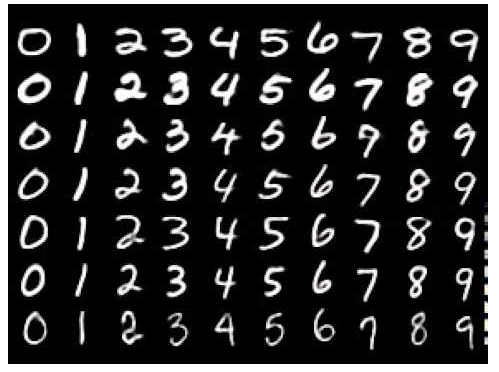

> 본 코드에서, batch size (모델 학습 중 parameter를 업데이트 할 때 사용할 데이터의 개수) 는 64로 설정한다.

> 모든 training set이 신경망을 통과한 횟수를 epoch이라 하며, 이 epoch은 50으로 설정하여 학습을 돌린다.

> 이러한 parameter를 다르게 실험해 보는 것 또한 딥러닝 알고리즘의 흐름을 이해하는데 도움이 될 수 있다.

In [ ]:
# 하이퍼파라미터

# Generator가 이미지를 생성할 때 입력으로 사용하는
# noise vector의 차원
n_noise = 100

# 한 번의 학습에 사용하는 데이터 개수
batch_size = 64

# 전체 데이터셋에 대한 최대 학습 반복 횟수
# Generator가 충분히 학습되기 위해 최소 10 epoch 이상 권장
max_epoch = 50

# 현재 학습 step
step = 0

# Generator의 학습 주기
# step이 n_critic의 배수일 때마다 Generator를 학습
n_critic = 1

In [ ]:
# MNIST 이미지에 적용할 전처리 정의
transform = transforms.Compose([
    # MNIST 이미지를 PyTorch Tensor로 변환
    # 픽셀값의 범위도 [0, 255] → [0, 1]로 변환
    transforms.ToTensor(),

    # 픽셀값을 평균 0.5, 표준편차 0.5를 기준으로 정규화
    # x_new = (x - 0.5) / 0.5
    #
    # 따라서 픽셀값의 범위가 [0, 1] → [-1, 1]로 변환됨
    # Generator의 마지막 Tanh 출력 범위 [-1, 1]과
    # Real Image의 픽셀 범위를 동일하게 맞추기 위해 사용
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# MNIST 학습 데이터셋 불러오기
# train=True이므로 Training Dataset을 사용
# 위에서 정의한 transform을 각 이미지에 적용
# 데이터가 존재하지 않으면 ../data/ 경로에 다운로드
trainset = datasets.MNIST(
    root='../data/',
    train=True,
    transform=transform,
    download=True
)

# MNIST 데이터셋을 batch 단위로 불러오기 위한 DataLoader 생성
#
# batch_size만큼의 이미지를 하나의 batch로 구성
# shuffle=True: 매 epoch마다 데이터 순서를 무작위로 섞음
# drop_last=True: 마지막 batch의 크기가 batch_size보다 작으면 해당 batch를 제외
#
# 따라서 모든 batch의 크기가 동일하게 유지됨
trainloader = DataLoader(
    dataset=trainset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.09MB/s]


In [ ]:
# trainloader에서 하나의 batch를 가져옴
batch = next(iter(trainloader))

# batch[0]은 이미지 데이터
# shape: [batch_size, channel, height, width]
#      = [64, 1, 28, 28]
# batch_size는 64, channel은 흑백 이미지이므로 1,
# 이미지 크기는 28 × 28
print(batch[0].shape)

# batch[1]은 각 이미지에 대응하는 정답(label)
# 각 이미지마다 하나의 스칼라 정답이 존재하므로
# shape: [batch_size] = [64]
print(batch[1].shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
# 현재 batch에 포함된 이미지 데이터
# shape: [64, 1, 28, 28]
# 64개의 흑백 이미지가 저장되어 있음
batch[0]

tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]],


        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]],


        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]],


        ...,


        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., 

In [ ]:
# 각 이미지에 대응하는 정답(label)
# shuffle=True이므로 0~9 사이의 숫자 이미지가 무작위 순서로 섞여 있음
batch[1]

tensor([0, 8, 9, 1, 2, 5, 8, 8, 8, 5, 2, 9, 9, 3, 7, 4, 4, 9, 8, 4, 3, 8, 5, 1,
        6, 0, 0, 7, 8, 1, 0, 4, 3, 6, 2, 6, 6, 4, 8, 0, 9, 7, 4, 7, 1, 8, 1, 7,
        9, 5, 9, 5, 3, 8, 3, 0, 7, 3, 9, 5, 9, 4, 8, 2])

## 2. Create Discriminator & Generator

> Fully-Connected Layer를 이용하여 Discriminator와 Generator를 구현한다.

> 먼저, Generator는 Noise z를 받아, 진짜와 동일한 것 같은 fake 이미지를 생성해내는 모델이다.

> 반면, Discriminator는 생성된 이미지 혹은 실제 이미지를 받아, Real (실제 이미지) 인지 Fake (Generator가 생성한 이미지) 인지를 판별하는 모델이다.

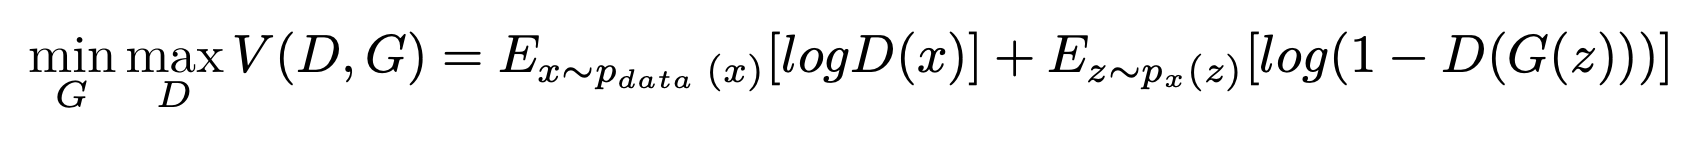


*   D 는 위 수식에 따라 D 가 real image를 real image로 판단할 확률을 maximize하며, 생성 된 fake image(G(z))가 real image로 판단될 확률을 minimize 한다.
*   G 입장에서는 생성된 fake image가 real image로 판단될 확률을 maximize 한다.
*   이 둘이 서로 min-max game을 펼치면서(지속적으로 학습시키면서) G 의 이미지 생성 기술, D 의 이미지 판별 기술이 성장하게 된다.

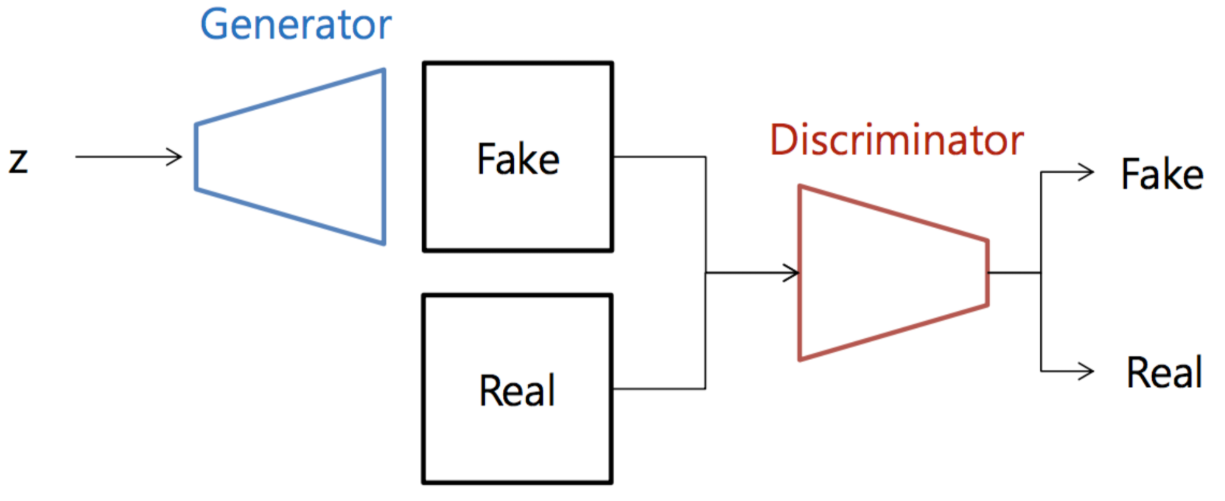

In [ ]:
class Discriminator(nn.Module):
    """
    MLP 기반의 Discriminator
    """
    def __init__(self, input_size=784, num_classes=1):
        super(Discriminator, self).__init__()

        # 입력 이미지를 1차원 벡터로 펼친 후 MLP를 통해 Real/Fake를 판별
        #
        # [64, 784] → [64, 512]
        # Linear 변환 후 LeakyReLU 적용
        #
        # [64, 512] → [64, 256]
        # Linear 변환 후 LeakyReLU 적용
        #
        # [64, 256] → [64, 1]
        # Linear 변환 후 Sigmoid 적용
        #
        # 최종적으로 각 이미지가 Real일 확률을 0~1 사이의 값으로 출력
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_classes),
            nn.Sigmoid(),
        )

    def forward(self, x):

        # 입력 x의 shape: [64, 1, 28, 28]
        # 각 이미지를 1차원 벡터로 펼쳐 [64, 784]로 변환
        # 첫 번째 차원(batch_size)은 유지하고 나머지 차원을 하나로 합침
        output = x.reshape(x.size(0), -1)

        # MLP를 통해 각 이미지가 Real일 확률을 계산
        # output의 shape: [64, 1]
        # 각 이미지마다 0~1 사이의 값 하나를 출력
        output = self.model(output)

        return output

In [ ]:
class Generator(nn.Module):
    """
    MLP 기반의 Generator
    """
    def __init__(self, input_size=100, num_classes=784):
        super(Generator, self).__init__()

        # 입력으로 [64, 100] 크기의 noise vector를 받아 이미지를 생성
        #
        # [64, 100] → [64, 128]
        # Linear 변환 후 LeakyReLU 적용
        #
        # [64, 128] → [64, 256]
        # Linear 변환 후 BatchNorm, LeakyReLU 적용
        #
        # [64, 256] → [64, 512]
        # Linear 변환 후 BatchNorm, LeakyReLU 적용
        #
        # [64, 512] → [64, 1024]
        # Linear 변환 후 BatchNorm, LeakyReLU 적용
        #
        # [64, 1024] → [64, 784]
        # Linear 변환 후 Tanh 적용
        #
        # 784 = 28 × 28이므로 하나의 28 × 28 이미지를
        # 1차원 벡터로 펼친 형태
        # Tanh를 통과하므로 각 픽셀값은 -1~1 범위를 가짐
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, num_classes),
            nn.Tanh()
        )

    def forward(self, x):

        # 입력 x의 shape: [64, 100]
        # 각 이미지 생성을 위한 100차원의 noise vector
        #
        # MLP를 통과하여 [64, 784] 크기의 이미지 벡터를 생성
        # 각 픽셀값의 범위는 -1~1
        output = self.model(x)

        # [64, 784] → [64, 1, 28, 28]로 변환
        # 즉, 펼쳐져 있던 이미지 벡터를 다시
        # [batch_size, channel, height, width] 형태로 복원
        output = output.reshape(x.size(0), 1, 28, 28)

        return output

In [ ]:
import torch.nn as nn

D = Discriminator().to(device)
G = Generator(n_noise).to(device)

In [ ]:
# Discriminator는 입력 이미지가 Fake(0)인지 Real(1)인지 판별하는
# 이진 분류기(Binary Classifier)이므로 Binary Cross Entropy를 Loss Function으로 사용
criterion = nn.BCELoss()

# Discriminator와 Generator의 Optimizer로 Adam을 사용
# 학습률(learning rate)은 0.0002로 설정
#
# betas=(0.5, 0.999)는 Adam에서 사용하는
# 1차 모멘트(평균)와 2차 모멘트(분산)의 지수이동평균 계수
# GAN 학습에서는 안정적인 학습을 위해 beta1을 기본값 0.9보다 낮은 0.5로 설정하는 경우가 많음
#
# beta 관련 내용은 MySUNI의 Adam 강의 참고
# 08_[딥러닝 모델 학습 및 평가 #1] Optimization
# → T-7-01-03_변형된 Gradient Descent 방법들(2) AdaGrad, RMSProp, Adam.mov

# Discriminator의 파라미터를 업데이트하기 위한 Optimizer
D_opt = torch.optim.Adam(
    D.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# Generator의 파라미터를 업데이트하기 위한 Optimizer
G_opt = torch.optim.Adam(
    G.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

> GAN 알고리즘의 loss는 real or fake를 판단하는 cross-entropy이므로 `nn.BCELoss()` 로 loss를 설정한다.

> Discriminator와 Generator를 학습을 번갈아가면서 진행한다. Discriminator는 실제 이미지는 `1` (Real)로, Generator가 생성한 이미지는 `0` (Fake)로 예측하도록 학습한다.

> 반면, Generator는 생성한 이미지가 Discriminator를 속일 수 있도록, 생성한 이미지가 Discriminator에 들어갔을 때 `1` (Real)로 예측하도록 학습한다.

> 이러한 학습 메커니즘을 잘 생각하고 아래 코드를 확인해보자. Learning Rate는 `0.0002` 로 설정하며, beta1=0.5, beta2=0.999 파라미터를 활용한다. 따라서, `betas=(0.5, 0.999)` 로 설정하여 학습을 진행한다.



In [ ]:
# 생성된 샘플 이미지를 저장할 디렉토리가 없으면 생성
if not os.path.exists('samples'):
    os.makedirs('samples')


# Real Image에 대한 Ground Truth
# Discriminator가 Real Image를 1로 판별하도록 모든 값을 1로 설정
# shape: [64, 1]
D_labels = torch.ones(batch_size, 1).to(device)

# Fake Image에 대한 Ground Truth
# Discriminator가 Generator가 생성한 Fake Image를 0으로 판별하도록 모든 값을 0으로 설정
# shape: [64, 1]
D_fakes = torch.zeros(batch_size, 1).to(device)


# 학습 과정에서 Discriminator와 Generator의 Loss를 저장할 리스트
D_loss_data = []
G_loss_data = []


for epoch in range(max_epoch):
    for idx, (images, _) in enumerate(trainloader):

        # ============================================================
        # 1. Discriminator 학습
        # ============================================================

        # trainloader에서 가져온 Real Image를 device로 이동
        # x의 shape: [64, 1, 28, 28]
        x = images.to(device)

        # Real Image를 Discriminator에 입력
        # 각 이미지가 Real일 확률을 0~1 사이의 값으로 출력
        # x_outputs의 shape: [64, 1]
        x_outputs = D(x)

        # Real Image에 대한 Discriminator의 출력과
        # Ground Truth인 1을 이용하여 Binary Cross Entropy Loss 계산
        #
        # 즉, Discriminator가 Real Image에 대해
        # 1에 가까운 값을 출력하도록 학습하기 위한 Loss
        #
        # x_outputs의 shape: [64, 1]
        # D_labels의 shape: [64, 1]
        D_x_loss = criterion(x_outputs, D_labels)


        # Generator가 Fake Image를 생성할 때 입력으로 사용할 noise 생성
        # randn은 평균이 0, 표준편차가 1인 표준 가우시안 분포에서 난수를 생성
        # z의 shape: [64, 100]
        z = torch.randn(batch_size, n_noise).to(device)

        # [64, 100]의 noise를 Generator에 입력하여
        # [64, 1, 28, 28] 크기의 Fake Image 생성
        #
        # 생성된 Fake Image를 다시 Discriminator에 입력하여
        # 각 Fake Image가 Real일 확률을 계산
        #
        # z_outputs의 shape: [64, 1]
        z_outputs = D(G(z))

        # Fake Image에 대한 Discriminator의 출력과
        # Ground Truth인 0을 이용하여 Binary Cross Entropy Loss 계산
        #
        # 즉, Discriminator가 Fake Image에 대해
        # 0에 가까운 값을 출력하도록 학습하기 위한 Loss
        #
        # z_outputs의 shape: [64, 1]
        # D_fakes의 shape: [64, 1]
        D_z_loss = criterion(z_outputs, D_fakes)

        # Real Image를 1로 판별하기 위한 Loss와
        # Fake Image를 0으로 판별하기 위한 Loss를 합산하여
        # 최종 Discriminator Loss 계산
        D_loss = D_x_loss + D_z_loss

        # 이전 학습 과정에서 계산되어 누적된
        # Discriminator 파라미터의 gradient를 초기화
        D.zero_grad()

        # D_loss를 기준으로 Backpropagation을 수행하여
        # Discriminator 파라미터들의 gradient 계산
        D_loss.backward()

        # 계산된 gradient를 이용하여
        # Discriminator의 파라미터 업데이트
        D_opt.step()


        # ============================================================
        # 2. Generator 학습
        # ============================================================

        # step이 n_critic의 배수일 때 Generator를 학습
        # 현재 n_critic = 1이므로 매 step마다 Generator를 학습
        if step % n_critic == 0:

            # Generator가 Fake Image를 생성할 때 사용할 새로운 noise 생성
            # randn은 평균이 0, 표준편차가 1인 표준 가우시안 분포에서 난수를 생성
            # z의 shape: [64, 100]
            z = torch.randn(batch_size, n_noise).to(device)

            # noise를 Generator에 입력하여 Fake Image를 생성하고
            # 생성된 Fake Image를 Discriminator에 입력
            #
            # Generator의 목적은 자신이 만든 Fake Image를
            # Discriminator가 Real이라고 판단하도록 만드는 것
            #
            # z_outputs의 shape: [64, 1]
            z_outputs = D(G(z))

            # Generator가 생성한 Fake Image에 대한 Discriminator의 출력과
            # Ground Truth를 1로 두고 Binary Cross Entropy Loss 계산
            #
            # 즉, Discriminator가 Fake Image를
            # Real Image(1)라고 판단하도록 Generator를 학습
            #
            # z_outputs의 shape: [64, 1]
            # D_labels의 shape: [64, 1]
            G_loss = criterion(z_outputs, D_labels)

            # 이전 학습 과정에서 누적된
            # Generator 파라미터의 gradient를 초기화
            G.zero_grad()

            # G_loss를 기준으로 Backpropagation을 수행하여
            # Generator 파라미터들의 gradient 계산
            G_loss.backward()

            # 계산된 gradient를 이용하여
            # Generator의 파라미터 업데이트
            G_opt.step()


        # ============================================================
        # 3. 학습 과정 출력 및 Loss 기록
        # ============================================================

        # 500 step마다 현재 학습 상태를 출력하고 Loss를 저장
        if step % 500 == 0:
            print(
                'Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(
                    epoch,
                    max_epoch,
                    step,
                    D_loss.item(),
                    G_loss.item()
                )
            )

            D_loss_data.append(float(D_loss.item()))
            G_loss_data.append(float(G_loss.item()))

        # 전체 학습 step 증가
        step += 1

Epoch: 0/50, Step: 0, D Loss: 1.3477048873901367, G Loss: 0.6948332786560059
Epoch: 0/50, Step: 500, D Loss: 1.3185011148452759, G Loss: 0.8597310185432434
Epoch: 1/50, Step: 1000, D Loss: 1.2067219018936157, G Loss: 0.943175196647644
Epoch: 1/50, Step: 1500, D Loss: 1.1786972284317017, G Loss: 0.7814988493919373
Epoch: 2/50, Step: 2000, D Loss: 1.1560757160186768, G Loss: 1.2305423021316528
Epoch: 2/50, Step: 2500, D Loss: 1.5224205255508423, G Loss: 1.5076003074645996
Epoch: 3/50, Step: 3000, D Loss: 1.1968705654144287, G Loss: 1.1175042390823364
Epoch: 3/50, Step: 3500, D Loss: 1.5296940803527832, G Loss: 0.5852681994438171
Epoch: 4/50, Step: 4000, D Loss: 1.2834017276763916, G Loss: 0.6209118962287903
Epoch: 4/50, Step: 4500, D Loss: 1.1630403995513916, G Loss: 0.8916707634925842
Epoch: 5/50, Step: 5000, D Loss: 1.2790074348449707, G Loss: 1.231649398803711
Epoch: 5/50, Step: 5500, D Loss: 1.209833025932312, G Loss: 1.1648521423339844
Epoch: 6/50, Step: 6000, D Loss: 1.284406900405

## 4. Visualization

> Generator가 생성한 이미지를 직접 시각화해 보자.

In [ ]:
def get_sample_image(G, n_noise):
    """
    Generator가 생성한 100개의 이미지를
    10 × 10 형태의 하나의 이미지로 결합하여 반환
    """

    # Generator에 입력할 100개의 noise vector 생성
    # randn은 평균이 0, 표준편차가 1인 표준 가우시안 분포에서 난수를 생성
    # z의 shape: [100, n_noise] = [100, 100]
    z = torch.randn(100, n_noise).to(device)

    # noise를 Generator에 입력하여 100개의 Fake Image 생성
    # G(z)의 shape: [100, 1, 28, 28]
    #
    # channel 차원을 제거하여
    # y_hat의 shape를 [100, 28, 28]로 변환
    y_hat = G(z).reshape(100, 28, 28)

    # Tensor를 CPU로 이동한 뒤 NumPy 배열로 변환
    # result의 shape: [100, 28, 28]
    result = y_hat.cpu().data.numpy()

    # 100개의 28 × 28 이미지를 10 × 10으로 배치하기 위한
    # 280 × 280 크기의 빈 이미지 생성
    # 280 = 28 × 10
    img = np.zeros([280, 280])

    # 한 번의 반복마다 10개의 이미지를 가로 방향으로 연결
    for j in range(10):

        # result에서 10개의 이미지 선택
        # 각각의 shape: [28, 28]
        #
        # 10개의 이미지를 가로 방향(axis=-1)으로 연결하여
        # [28, 280] 크기의 한 행(row)을 생성
        #
        # 생성한 행을 img의 해당 위치에 삽입하여
        # 최종적으로 10 × 10 형태의 이미지 배열을 생성
        img[j*28:(j+1)*28] = np.concatenate(
            [x for x in result[j*10:(j+1)*10]],
            axis=-1
        )

    # 100개의 생성 이미지가 10 × 10으로 배치된
    # [280, 280] 크기의 NumPy 배열 반환
    return img

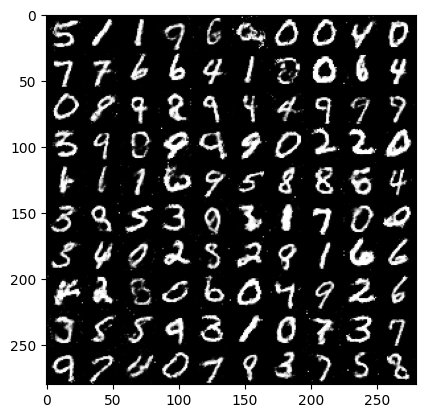

In [ ]:
# 이미지 생성 결과 조회
G.eval()
plt.imshow(get_sample_image(G, n_noise), cmap='gray')

> 상단 이미지는 GAN이 생성한 이미지이다.

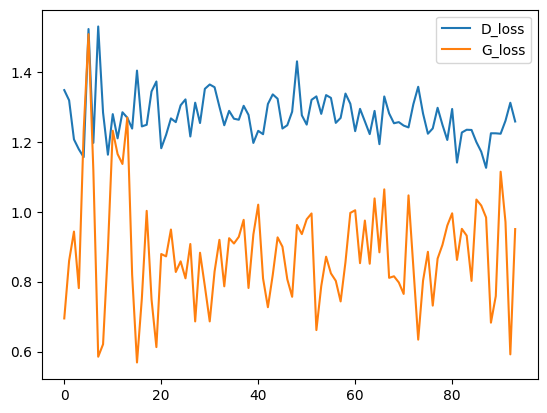

In [ ]:
plt.plot(D_loss_data, label='D_loss')
plt.plot(G_loss_data, label='G_loss')
plt.legend()
plt.show()

> Discriminator와 Generator loss를 plot한 결과는 위와 같다.

In [ ]:
# 파라미터 저장
torch.save(D.state_dict(), 'D.pkl')
torch.save(G.state_dict(), 'G.pkl')

> 학습한 모델의 weight는 위와 같은 방식으로 저장할 수 있다.